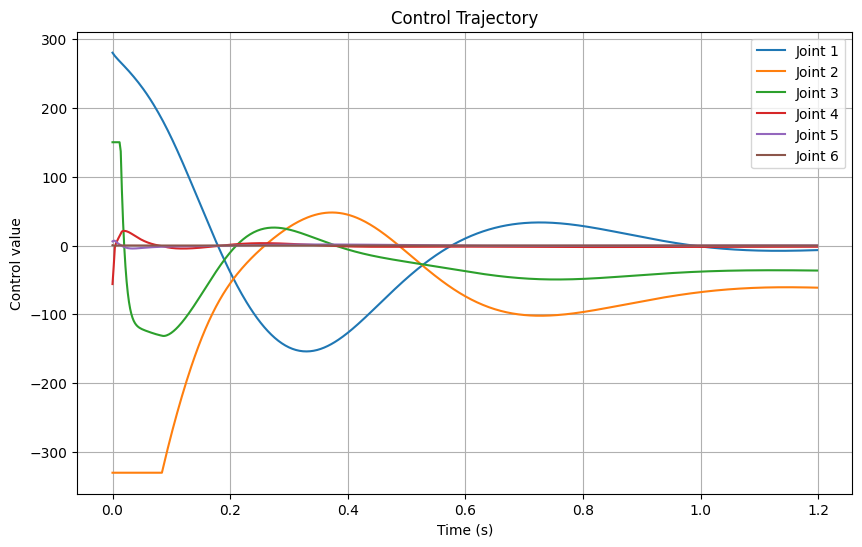

In [2]:
from optimal.PDController import PDController
from optimal.Visualizer import Visualizer
import pinocchio as pin
import numpy as np
import mujoco

mjcf_path = "../models/ur10/ur10.xml"
urdf_path = "../models/ur10/ur10.urdf"
robot_mj_model = mujoco.MjModel.from_xml_path(mjcf_path)
robot_pin_model = pin.buildModelFromUrdf(urdf_path)

kp = np.array([400.0, 800.0, 400.0, 100.0, 4.0, 1.0])
kd = np.array([40.0,  80.0,  40.0,  10.0,  .4,  .1])
pd_controller = PDController(robot_pin_model, kp=kp, kd=kd)

DT = robot_mj_model.opt.timestep
q_start = pin.neutral(robot_pin_model)
q_target = np.array([0.7, -1.2, 1.5, -0.8, 1.5, 0.5])
xs, us = pd_controller.compute_control(x_start=q_start, x_goal=q_target, horizon=600, control_dt=DT)

robot_mj_data = mujoco.MjData(robot_mj_model)
viewer = Visualizer(robot_mj_model, robot_mj_data)
viewer.plot_controls(us, dt=DT)

In [6]:
# import optimal.DifferentialFreeFwdDynamicsModelDerived
import crocoddyl

q0 = pin.neutral(robot_pin_model)
x0 = np.concatenate([q0, np.zeros(robot_pin_model.nv)])

q_start = pin.neutral(robot_pin_model)
q_target = np.array([0.7, -1.2, 1.5, -0.8, 1.5, 0.5])

robot_data = robot_pin_model.createData()
pin.forwardKinematics(robot_pin_model, robot_data, q0)
pin.updateFramePlacements(robot_pin_model, robot_data)
state = crocoddyl.StateMultibody(robot_pin_model)
# framePlacementResidual = crocoddyl.ResidualModelFramePlacement(
#     state, robot_pin_model.getFrameId("wrist_3_link"), pin.SE3(target_rot, target_pos),
# )
framePlacementResidual = crocoddyl.ResidualModelState(state, np.concatenate([q_target, np.zeros(robot_pin_model.nv)]))
goalTrackingCost = crocoddyl.CostModelResidual(state, framePlacementResidual)
# xRegCost = crocoddyl.CostModelResidual(state, crocoddyl.ResidualModelState(state))
uRegCost = crocoddyl.CostModelResidual(state, crocoddyl.ResidualModelControl(state))

# Create cost model per each action model
runningCostModel = crocoddyl.CostModelSum(state)
terminalCostModel = crocoddyl.CostModelSum(state)

# Then let's added the running and terminal cost functions
runningCostModel.addCost("gripperPose", goalTrackingCost, 1e2)
# runningCostModel.addCost("stateReg", xRegCost, 1e-4)
runningCostModel.addCost("ctrlReg", uRegCost, 6e-2)
terminalCostModel.addCost("gripperPose", goalTrackingCost, 1e5)
# terminalCostModel.addCost("stateReg", xRegCost, 1e-4)
# terminalCostModel.addCost("ctrlReg", uRegCost, 1e-7)

# Running and terminal action models
DT = robot_mj_model.opt.timestep
actuationModel = crocoddyl.ActuationModelFull(state)
runningModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuationModel, runningCostModel
    ),
    DT,
)
terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuationModel, terminalCostModel
    ),
    0.0,
)

In [ ]:
import time

import pinocchio
# For this optimal control problem, we define 250 knots (or running action
# models) plus a terminal knot
T = 600
print(len(x0[:6]))
print(x0)
u0 = np.zeros(actuationModel.nu * T)
robot_mj_data = mujoco.MjData(robot_mj_model)
print(robot_mj_data.xpos[mujoco.mj_name2id(robot_mj_model, mujoco.mjtObj.mjOBJ_BODY, "wrist_3_link")])
# compute xyz position of wrist_3_link using joint positions and forward kinematics
robot_data = robot_pin_model.createData()
pin.forwardKinematics(robot_pin_model, robot_data, q0)
pin.updateFramePlacements(robot_pin_model, robot_data)
frame_id = robot_pin_model.getFrameId("wrist_3_link")
wrist_pos = robot_data.oMf[frame_id].translation
print("wrist_3_link position (Pinocchio FK):", wrist_pos)

problem = crocoddyl.ShootingProblem(x0, [runningModel] * T, terminalModel)

xs, us = pd_controller.compute_control(x_start=q_start, x_goal=q_target, horizon=T, control_dt=DT)
# Creating the Box-constrained DDP solver for this OC problem to enforce torque limits
solver = crocoddyl.SolverBoxFDDP(problem)
solver.solve(xs, us, 100, False)
log = crocoddyl.CallbackLogger()
pin.forwardKinematics(robot_pin_model, robot_data, robot_mj_data.qpos)

print(robot_mj_data.ctrl)
viewer = Visualizer(robot_mj_model, robot_mj_data)
viewer.setup_camera(lookat=np.array([0.0, 0.0, 0.7]), distance=3.5, azimuth=90, elevation=-30)
robot_mj_data.qpos = pin.neutral(robot_pin_model)
robot_mj_data.qvel[:] = 0.0
mujoco.mj_forward(robot_mj_model, robot_mj_data)
# viewer.visualize(mode="control", vector=solver.us, dt=DT)
# viewer.visualize(mode="position", vector=solver.xs, dt=DT)
viewer.visualize(mode="control", vector=solver.us, dt=DT)

# print position of wrist_3_link
print(robot_mj_data.xpos[mujoco.mj_name2id(robot_mj_model, mujoco.mjtObj.mjOBJ_BODY, "wrist_3_link")])

pinocchio.forwardKinematics(robot_pin_model, robot_data, robot_mj_data.qpos)
pinocchio.updateFramePlacements(robot_pin_model, robot_data)
frame_id = robot_pin_model.getFrameId("wrist_3_link")
wrist_pos = robot_data.oMf[frame_id].translation
print("wrist_3_link position (Pinocchio FK):", wrist_pos)

6
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0.]


NameError: name 'pinocchio' is not defined